In [5]:
!pip install innvestigate

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=794a3dc9a40bb0edaf3c4b5ca8152f872d9a556cb39c1a078b88f990d2e4bf71
  Stored in directory: /root/.cache/pip/wheels/15/0c/b3/674aea8c5d91c642c817d4d630bd58faa316724b136844094d
Successfully built utils


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.simplefilter("ignore")

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
import shutil
import urllib

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.backend import image_data_format

import innvestigate
import innvestigate.utils as iutils
import innvestigate.utils.visualizations as ivis

tf.compat.v1.disable_eager_execution()

In [10]:
def download(url, filename):
    if not os.path.exists(filename):
        print(f"Download: {url} ---> {filename}")
        response = urllib.request.urlopen(url)
        with open(filename, "wb") as out_file:
            shutil.copyfileobj(response, out_file)

In [11]:
def load_image(path, size):
    ret = PIL.Image.open(path)
    ret = ret.resize((size, size))
    ret = np.asarray(ret).astype(np.float32)
    if ret.ndim == 2:
        ret.resize((size, size, 1))
        ret = np.repeat(ret, 3, axis=-1)
    return ret


def plot_image_grid(
    grid,
    row_labels_left,
    row_labels_right,
    col_labels,
    file_name=None,
    figsize=None,
    dpi=224,
):
    n_rows = len(grid)
    n_cols = len(grid[0])
    if figsize is None:
        figsize = (n_cols, n_rows + 1)

    plt.clf()
    plt.rc("font", family="sans-serif")
    plt.figure(figsize=figsize)
    for r in range(n_rows):
        for c in range(n_cols):
            ax = plt.subplot2grid(shape=[n_rows + 1, n_cols], loc=[r + 1, c])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if grid[r][c] is not None:
                ax.imshow(grid[r][c], interpolation="none")
            else:
                for spine in plt.gca().spines.values():
                    spine.set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])

            if not r and col_labels:
                ax.set_title(col_labels[c], rotation=22.5, ha="left", va="bottom")

            if not c and row_labels_left:
                ax.set_ylabel("\n".join(row_labels_left[r]), rotation=0, va="center", ha="right")

            if c == n_cols - 1 and row_labels_right:
                ax2 = ax.twinx()
                for spine in ax2.spines.values():
                    spine.set_visible(False)
                ax2.set_xticks([])
                ax2.set_yticks([])
                ax2.set_ylabel("\n".join(row_labels_right[r]), rotation=0, va="center", ha="left")

    if file_name is None:
        plt.show()
    else:
        print(f"Saving figure to {file_name}")
        plt.savefig(file_name, orientation="landscape", dpi=dpi, bbox_inches="tight")
        plt.show()

In [12]:
from tensorflow.keras.datasets import mnist


def fetch_data():
    channels_first = image_data_format() == "channels_first"
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    if channels_first:
        x_train = x_train.reshape(60000, 1, 28, 28)
        x_test = x_test.reshape(10000, 1, 28, 28)
    else:
        x_train = x_train.reshape(60000, 28, 28, 1)
        x_test = x_test.reshape(10000, 28, 28, 1)

    x_train = x_train.astype("float32")
    x_test = x_test.astype("float32")

    return x_train, y_train, x_test, y_test


def create_preprocessing_f(X, input_range=None):
    if input_range is None:
        input_range = [0, 1]
    a, b = X.min(), X.max()
    c, d = input_range

    def preprocessing(X):
        X = np.expand_dims(X, -1).astype(np.float32)
        X = (X - a) / (b - a) * (d - c) + c
        return X

    def revert_preprocessing(X):
        X = (X - c) / (d - c) * (b - a) + a
        return X

    return preprocessing, revert_preprocessing


def train_model(model, data, batch_size=128, epochs=20):
    num_classes = 10
    x_train, y_train, x_test, y_test = data
    y_train = keras.utils.to_categorical(y_train, num_classes)
    y_test = keras.utils.to_categorical(y_test, num_classes)

    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1)
    score = model.evaluate(x_test, y_test, verbose=0)
    return score


def postprocess(X):
    return iutils.postprocess_images(X)


def bk_proj(X):
    return ivis.graymap(X)


def heatmap(X):
    return ivis.heatmap(X)


def graymap(X):
    return ivis.graymap(np.abs(X), input_is_positive_only=True)

### Data

In [14]:
# Load data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Create preprocessing functions
input_range = [-1, 1]
preprocess, revert_preprocessing = create_preprocessing_f(x_train, input_range)

# Preprocess data
data = (
    preprocess(x_train),
    y_train,
    preprocess(x_test),
    y_test,
)

num_classes = len(np.unique(data[1]))
label_to_class_name = [str(i) for i in range(num_classes)]

### Model

In [15]:
# Create & train model
input_shape = (28, 28, 1)

model = keras.models.Sequential(
    [
        keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

scores = train_model(model, data, batch_size=128, epochs=10)
print("Scores on test set: loss=%s accuracy=%s" % tuple(scores))

Train on 60000 samples
Epoch 1/10
60000/60000 [==============================] - 88s 1ms/sample - loss: 0.1382 - accuracy: 0.9580
Epoch 2/10
60000/60000 [==============================] - 92s 2ms/sample - loss: 0.0356 - accuracy: 0.9891
Epoch 3/10
60000/60000 [==============================] - 82s 1ms/sample - loss: 0.0230 - accuracy: 0.9923
Epoch 4/10
60000/60000 [==============================] - 75s 1ms/sample - loss: 0.0143 - accuracy: 0.9953
Epoch 5/10
60000/60000 [==============================] - 73s 1ms/sample - loss: 0.0093 - accuracy: 0.9970
Epoch 6/10
60000/60000 [==============================] - 72s 1ms/sample - loss: 0.0074 - accuracy: 0.9974
Epoch 7/10
60000/60000 [==============================] - 72s 1ms/sample - loss: 0.0065 - accuracy: 0.9977
Epoch 8/10
60000/60000 [==============================] - 72s 1ms/sample - loss: 0.0066 - accuracy: 0.9980
Epoch 9/10
60000/60000 [==============================] - 72s 1ms/sample - loss: 0.0045 - accuracy: 0.9987
Epoch 10/10
60

## Analysis

In [16]:
# Scale to [0, 1] range for plotting.
def input_postprocessing(X):
    return revert_preprocessing(X) / 255


noise_scale = (input_range[1] - input_range[0]) * 0.1
ri = input_range[0]  # reference input

# Configure analysis methods and properties
# fmt: off
methods = [
    # NAME                    OPT.PARAMS                POSTPROC FXN            TITLE
    # Show input
    ("input",               {},                         input_postprocessing,   "Input"),
    # Function
    ("gradient",            {"postprocess": "abs"},     graymap,     "Gradient"),
    ("smoothgrad",
                            {"noise_scale": noise_scale, 
                             "postprocess": "square"},  graymap,     "SmoothGrad"),
    # Signal
    ("deconvnet",           {},                         bk_proj,     "Deconvnet"),
    ("guided_backprop",     {},                         bk_proj,     "Guided Backprop"),
    # Interaction
    ("deep_taylor.bounded", {"low": input_range[0], 
                             "high": input_range[1]},   heatmap,     "DeepTaylor"),
    ("input_t_gradient",    {},                         heatmap,     "Input * Gradient"),
    ("integrated_gradients",{"reference_inputs": ri},   heatmap,     "Integrated Gradients"),
    ("lrp.z",               {},                         heatmap,     "LRP-Z"),
    ("lrp.epsilon",         {"epsilon": 1},             heatmap,     "LRP-Epsilon"),
]
# fmt: on

In [18]:
# Create model without trailing softmax
model_wo_softmax = innvestigate.model_wo_softmax(model)

# Create analyzers.
analyzers = [
    innvestigate.create_analyzer(method[0], model_wo_softmax, **method[1])
    for method in methods
]

In [19]:
%%capture

n = 10
test_images = list(zip(data[2][:n], data[3][:n]))

analysis = np.zeros([len(test_images), len(analyzers), 28, 28, 3])
text = []


for i, (x, y) in enumerate(test_images):
    # Add batch axis.
    x = x[None, :, :, :]

    # Predict final activations, probabilites, and label.
    presm = model_wo_softmax.predict_on_batch(x)[0]
    prob = model.predict_on_batch(x)[0]
    y_hat = prob.argmax()

    # Save prediction info:
    text.append(
        (
            "%s" % label_to_class_name[y],  # ground truth label
            "%.2f" % presm.max(),  # pre-softmax logits
            "%.2f" % prob.max(),  # probabilistic softmax output
            "%s" % label_to_class_name[y_hat],  # predicted label
        )
    )

    for aidx, analyzer in enumerate(analyzers):
        # Analyze.
        a = analyzer.analyze(x)
        # Apply common postprocessing, e.g., re-ordering the channels for plotting.
        a = postprocess(a)
        # Apply analysis postprocessing, e.g., creating a heatmap.
        a = methods[aidx][2](a)
        # Store the analysis.
        analysis[i, aidx] = a[0]

<Figure size 640x480 with 0 Axes>

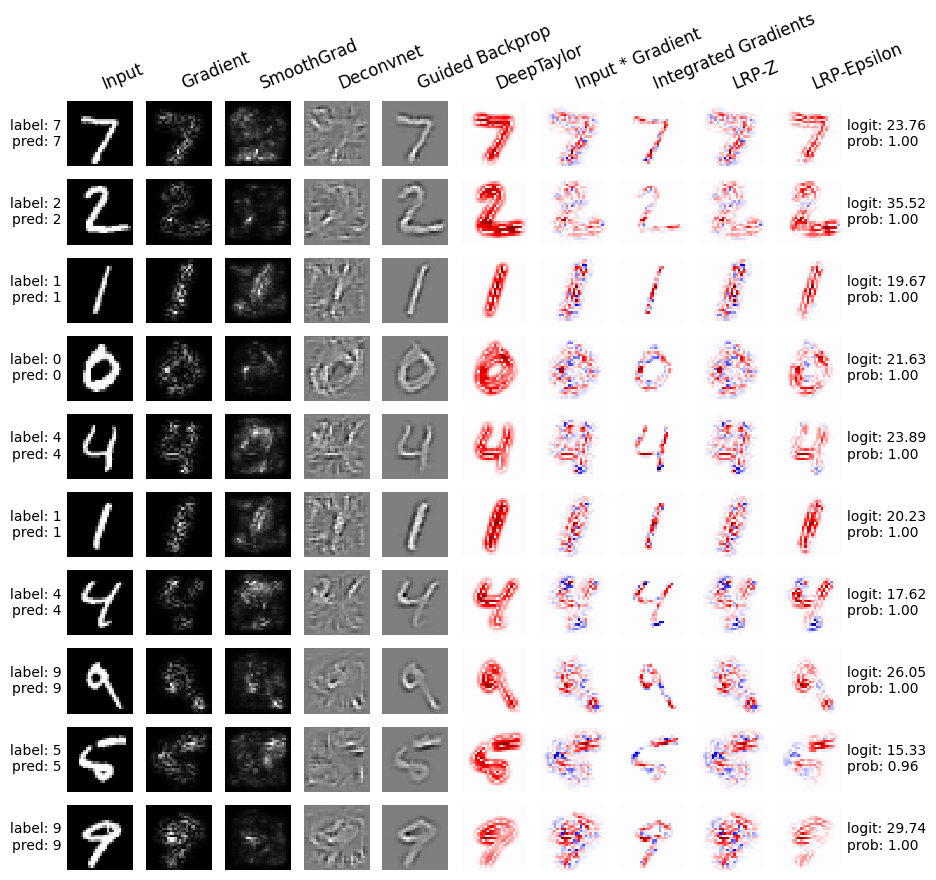

In [20]:
# Prepare the grid as rectengular list
grid = [
    [analysis[i, j] for j in range(analysis.shape[1])] for i in range(analysis.shape[0])
]
# Prepare the labels
label, presm, prob, pred = zip(*text)
row_labels_left = [
    (f"label: {label[i]}", f"pred: {pred[i]}") for i in range(len(label))
]
row_labels_right = [
    (f"logit: {presm[i]}", f"prob: {prob[i]}") for i in range(len(label))
]
col_labels = ["".join(method[3]) for method in methods]

# Plot the analysis.
plot_image_grid(
    grid,
    row_labels_left,
    row_labels_right,
    col_labels,
    file_name=os.environ.get("PLOTFILENAME", None),
)